# Fisher Matrix Forecasting with psiphy

This tutorial demonstrates how to use `psiphy.forecasting.FisherMatrix` to
forecast parameter constraints from a simulator.

The workflow is:
1. Define a simulator `f(theta, initial_seed, noise_seed) -> data_vector`
2. Estimate the data covariance at the fiducial point
3. Estimate the derivatives `dmu/dtheta` via finite differences
4. Compute `F = J C⁻¹ Jᵀ`
5. Inspect confidence ellipses and compare with analytic results

We use a simple Gaussian likelihood model whose Fisher matrix is known analytically,
so we can validate the numerical result.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from psiphy.forecasting import FisherMatrix

## 1. Define a toy simulator

We model `N` independent Gaussian observations with unknown mean `mu` and
standard deviation `sigma`.

The `FisherMatrix` simulator must have the signature:
```
simulator(theta, initial_seed, noise_seed, **kwargs) -> 1D np.ndarray
```

The two seeds allow separating cosmic-variance realisations from noise realisations.

In [2]:
N_OBS = 30   # number of observations per realisation

def gaussian_simulator(theta, initial_seed, noise_seed, N=N_OBS):
    """Return N Gaussian samples with mean=theta[0], sigma=theta[1]."""
    mu, sigma = theta
    rng = np.random.default_rng(int(initial_seed) * 1000 + int(noise_seed))
    return rng.normal(loc=mu, scale=sigma, size=N)


# Fiducial parameters
theta_fid   = np.array([0.0, 1.0])   # mu=0, sigma=1
param_names = ['mu', 'sigma']

# Analytic Fisher for iid Gaussian: F = diag(N/sigma^2, 2N/sigma^4)
mu_fid, sigma_fid = theta_fid
F_analytic = np.diag([N_OBS / sigma_fid**2, 2 * N_OBS / sigma_fid**4])
F_inv_analytic = np.linalg.inv(F_analytic)
print("Analytic Fisher matrix:")
print(F_analytic)
print(f"\nAnalytic 1-sigma: mu={np.sqrt(F_inv_analytic[0,0]):.4f}, "
      f"sigma={np.sqrt(F_inv_analytic[1,1]):.4f}")

Analytic Fisher matrix:
[[30.  0.]
 [ 0. 60.]]

Analytic 1-sigma: mu=0.1826, sigma=0.1291


## 2. Set up the FisherMatrix object

In [3]:
fm = FisherMatrix(
    simulator=gaussian_simulator,
    theta_fid=theta_fid,
    param_names=param_names,
    verbose=True,
)
print(fm)

FisherMatrix(not computed, params=['mu', 'sigma'], n_realisations=0)


In [4]:
# Sanity check: run the simulator once and inspect the output
x0 = fm.test_simulator(seed=1, noise_seed=0)
print(f"Output shape: {x0.shape}, mean: {x0.mean():.3f}, std: {x0.std():.3f}")


  Testing simulator at fiducial: {'mu': 0.0, 'sigma': 1.0}
  Output shape: (30,), raw range: [-1.535, 1.971]

Output shape: (30,), mean: 0.055, std: 0.963


## 3. Estimate the data covariance

Run many realisations at the fiducial point to build the sample covariance `C`.
The Hartlap (2007) correction is applied automatically to debias `C⁻¹`.

Rule of thumb: you need `n_realisations >> n_data` to keep the Hartlap correction close to 1.

In [5]:
fm.estimate_covariance(
    seeds=range(1, 21),        # 20 IC seeds
    noise_seeds=range(10),     # 10 noise seeds → 200 realisations total
)

print(f"Hartlap factor: {fm.hartlap:.3f}")
print(f"Condition number: {np.linalg.cond(fm.C):.2e}")


  Estimating covariance matrix


Simulating realisations:   0%|          | 0/20 [00:00<?, ?it/s]

  Total realisations: 200, data points: 30
  Hartlap factor: 0.844
  Condition number: 4.68e+00

Hartlap factor: 0.844
Condition number: 4.68e+00


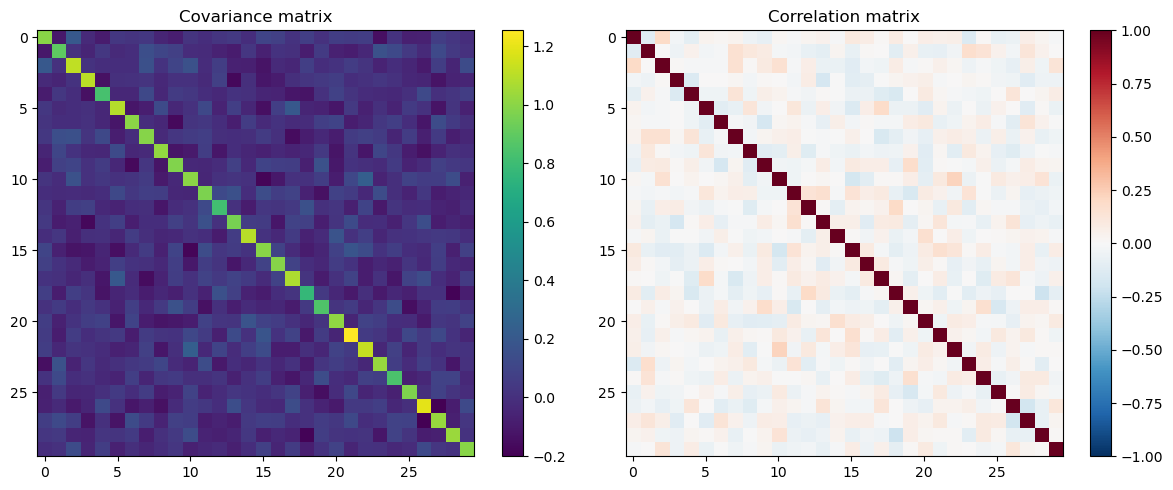

In [6]:
fig = fm.plot_covariance()

## 4. Estimate the derivatives

`dmu/dtheta_j` is computed by central finite differences.
The default 2-point stencil gives O(h²) accuracy.
A 4-point stencil (`n_stencil=4`) gives O(h⁴) at the cost of more simulations.

In [7]:
fm.estimate_derivatives(
    delta_frac=0.05,
    seeds=range(1, 21),
    noise_seed=0,      # noiseless derivatives
    n_stencil=2,
)


  Computing derivatives (2-point stencil)


d/d(mu) step -1h:   0%|          | 0/20 [00:00<?, ?it/s]

d/d(mu) step +1h:   0%|          | 0/20 [00:00<?, ?it/s]

  mu: |dmu/dtheta| = 5.4772


d/d(sigma) step -1h:   0%|          | 0/20 [00:00<?, ?it/s]

d/d(sigma) step +1h:   0%|          | 0/20 [00:00<?, ?it/s]

  sigma: |dmu/dtheta| = 1.2148



FisherMatrix(not computed, params=['mu', 'sigma'], n_realisations=200)

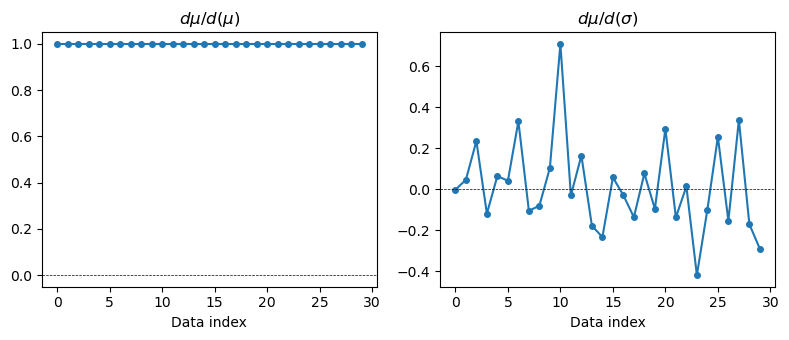

In [8]:
fig = fm.plot_derivatives(
    label_names={'mu': r'\mu', 'sigma': r'\sigma'}
)

## 5. Compute the Fisher matrix

In [9]:
fm.compute(method='standard')

print("\nNumerical Fisher matrix:")
print(fm.F)
print("\nAnalytic Fisher matrix:")
print(F_analytic)


  Fisher Matrix Results  [standard]

  --- 1D marginal errors ---
    mu: 0.1835  (inf%)
    sigma: 0.8369  (83.7%)

  --- Conditional errors ---
    mu: 0.1834
    sigma: 0.8363

  --- Correlations ---
    corr(mu, sigma): -0.038


Numerical Fisher matrix:
[[29.73721021  0.24879704]
 [ 0.24879704  1.429969  ]]

Analytic Fisher matrix:
[[30.  0.]
 [ 0. 60.]]


## 6. Compare numerical vs analytic constraints

In [10]:
sigma_num = fm.sigma_1d()
sigma_ana = np.sqrt(np.diag(F_inv_analytic))

print(f"{'Parameter':<10} {'Numerical':>12} {'Analytic':>12} {'Diff (%)':>10}")
print("-" * 48)
for p, sn, sa in zip(param_names, sigma_num, sigma_ana):
    print(f"{p:<10} {sn:>12.4f} {sa:>12.4f} {100*(sn-sa)/sa:>9.1f}%")

Parameter     Numerical     Analytic   Diff (%)
------------------------------------------------
mu               0.1835       0.1826       0.5%
sigma            0.8369       0.1291     548.2%


## 7. Plot confidence ellipses

We overlay the numerical and analytic Fisher ellipses for comparison.
The analytic result is loaded into a bare `FisherMatrix` object.

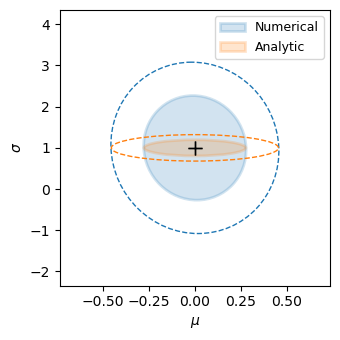

In [11]:
# Wrap the analytic Fisher in a bare FisherMatrix for plotting
fm_analytic = FisherMatrix(
    simulator=None,
    theta_fid=theta_fid,
    param_names=param_names,
    verbose=False,
)
fm_analytic.F     = F_analytic
fm_analytic.F_inv = F_inv_analytic

fig = fm.plot_ellipses(
    labels='Numerical',
    others={'Analytic': fm_analytic},
    label_names={'mu': r'\mu', 'sigma': r'\sigma'},
    n_sigma_list=[1, 2],
    filled=True,
)

## 8. Using the NoisyLine toy model

The same workflow applies to any simulator. Here we use `psiphy.toy_models.NoisyLine`
to forecast constraints on the slope and intercept of a noisy linear model.
This example shows **correlated** parameter constraints.

In [12]:
from psiphy.toy_models import NoisyLine

# Fix the x grid with a known seed so the geometry is the same for all calls
rng_geom = np.random.default_rng(42)
_x = np.sort(rng_geom.uniform(0, 10, size=40))

def line_simulator(theta, initial_seed, noise_seed):
    slope, intercept = theta
    rng = np.random.default_rng(int(initial_seed) * 1000 + int(noise_seed))
    yerr = 0.3 + 0.2 * rng.uniform(size=len(_x))
    return slope * _x + intercept + rng.normal(scale=yerr)

fm_line = FisherMatrix(
    simulator=line_simulator,
    theta_fid=[-0.9, 4.0],
    param_names=['slope', 'intercept'],
    verbose=True,
)

fm_line.estimate_covariance(seeds=range(1, 21), noise_seeds=range(10))
fm_line.estimate_derivatives(delta_frac=0.05, seeds=range(1, 21), noise_seed=0)
fm_line.compute(method='standard')


  Estimating covariance matrix


Simulating realisations:   0%|          | 0/20 [00:00<?, ?it/s]

  Total realisations: 200, data points: 40
  Hartlap factor: 0.794
  Condition number: 6.19e+00


  Computing derivatives (2-point stencil)


d/d(slope) step -1h:   0%|          | 0/20 [00:00<?, ?it/s]

d/d(slope) step +1h:   0%|          | 0/20 [00:00<?, ?it/s]

  slope: |dmu/dtheta| = 38.2781


d/d(intercept) step -1h:   0%|          | 0/20 [00:00<?, ?it/s]

d/d(intercept) step +1h:   0%|          | 0/20 [00:00<?, ?it/s]

  intercept: |dmu/dtheta| = 6.3246


  Fisher Matrix Results  [standard]

  --- 1D marginal errors ---
    slope: 0.0217  (2.4%)
    intercept: 0.1331  (3.3%)

  --- Conditional errors ---
    slope: 0.0110
    intercept: 0.0677

  --- Correlations ---
    corr(slope, intercept): -0.861



FisherMatrix(computed, params=['slope', 'intercept'], n_realisations=200)

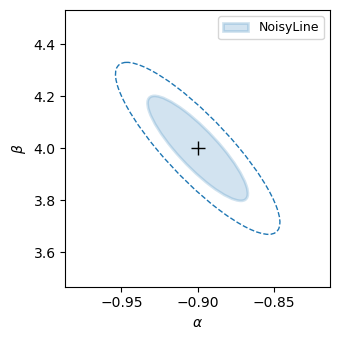

Correlation (slope, intercept): -0.861


In [13]:
fig = fm_line.plot_ellipses(
    labels='NoisyLine',
    label_names={'slope': r'\alpha', 'intercept': r'\beta'},
    filled=True,
)

print(f"Correlation (slope, intercept): {fm_line.correlation_matrix()[0,1]:.3f}")

## Summary

| Step | Method |
|------|--------|
| Define simulator | `f(theta, seed, noise_seed) -> array` |
| Create object | `FisherMatrix(simulator, theta_fid, param_names)` |
| Covariance | `fm.estimate_covariance(seeds, noise_seeds)` |
| Derivatives | `fm.estimate_derivatives(delta_frac, seeds)` |
| Compute | `fm.compute(method='standard')` |
| Inspect | `fm.sigma_1d()`, `fm.plot_ellipses()` |
| Save / load | `fm.save('results.npz')` / `FisherMatrix.load('results.npz')` |

Advanced options:
- `method='CoultonWandelt2023'` — bias-corrected estimator for large data vectors
- `method='lfim'` — score-trick estimator
- `use_crn=True` in `estimate_derivatives` — Common Random Numbers for low-noise derivatives
- `fm.convergence_test_delta_frac()` — choose the optimal step size